In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt

import src.device as device
import src.plotting as plotter
from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.HGPCode import HGPCode
from src.QECCode import TestCode

In [2]:
d = 5
dev = device.UnitCellDevice(d+2, d+2, device.hardware_params(1e-3))
code = RotatedSurfaceCode(d)

data_coords = {q:((code.qubit_coords[q][0]+1)//2, (code.qubit_coords[q][1]+1)//2) for q in code.data_indices}
assert len(set(data_coords.values())) == len(data_coords)
sched = dev.compile_QEC_schedule(
    code,
    data_coords,
    code.check_cx_layers,
    rounds=1,
    use_highways=True,
    refocus_shuttle_noise=False,
    optimize_ancilla_start=False,
)

[25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]
Optimizing 24 ancilla schedules........................

In [3]:
for instr,t in zip(sched.instructions, sched.instruction_start_times):
    print(t, instr)

0 Instantiate(duration=500, error=0.001, qubits=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24], cell_coords=[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5)])
500 EmplaceDisplace(duration=100, error=1e-06, qubit=0, coords=(1, 1), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, error=1e-06, qubit=1, coords=(1, 2), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, error=1e-06, qubit=2, coords=(1, 3), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, error=1e-06, qubit=3, coords=(1, 4), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, error=1e-06, qubit=4, coords=(1, 5), start_component=READOUT, end_component=INTERACTION_ZONE)
500 Em

413


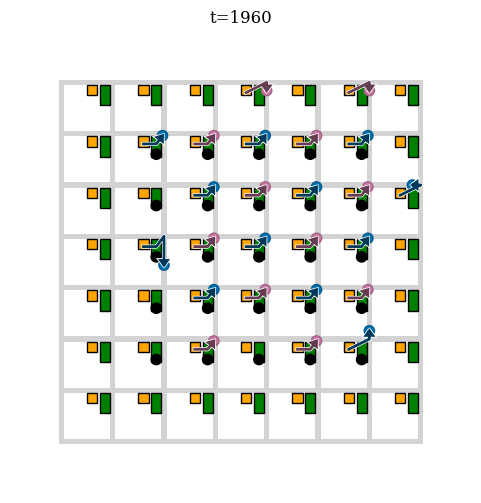

In [4]:
frames = sched.get_frames(20)
print(len(frames))
plotter.plot_transition(dev, code, frames[0:100])
plt.savefig('test.pdf')

MovieWriter imagemagick unavailable; using Pillow instead.


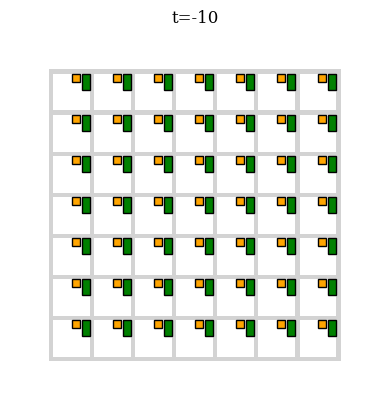

In [5]:
frames = sched.get_frames(10)
# plotter.plot_device_snapshot(dev, code, frames[50])
anim = plotter.animate_device(dev, code, frames, 'anim_surface.gif', fps=30)